#FBI Wanted List — Exploratory Data Analysis

##Overview
This project analyzes data pulled from the FBI's public "Wanted API" to answer the question:

**What patterns exist in the demographics, crime types, and reward structures of individuals on the FBI Wanted List?**

We examined 1,136 records and looked at crime categories, demographic breakdowns, reward amounts, physical profiles, and trends over time.

In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import datetime
import requests

## Data Collection
Data was pulled directly from the FBI's public API at https://api.fbi.gov/wanted/v1/list.
The API returns 20 records per page. We looped through all 57 pages to collect all 1,136 available records.

In [121]:
#pull data from FBI API

all_records = []

for page_number in range(1, 58):
    url = 'https://api.fbi.gov/wanted/v1/list'
    params = {'page': page_number}

    response = requests.get(url, params=params)
    data = response.json()

    #add the page's 20 records to main list
    all_records.extend(data['items'])

In [122]:
#convert to dataframe

df = pd.DataFrame(all_records)

df.head()

,ncic,race,height_min,description,eyes,modified,remarks,publication,hair,suspects,...,dates_of_birth_used,uid,images,field_offices,complexion,race_raw,eyes_raw,weight,title,pathId
0,None,hispanic,65.0,Conspiracy to Commit Bank Fraud; Conspiracy to...,brown,2026-03-13T20:27:14+00:00,<p>Canelon Aguirre has ties to Venezuela and M...,2026-02-17T11:44:00,black,None,...,"[May 15, 1976]",610d8fa337874ea7b7f09b992c4ea0b9,"[{'caption': 'Photograph taken in 2023', 'thum...",[omaha],None,White (Hispanic),Brown,190 pounds,ANIBAL ALEXANDER CANELON AGUIRRE,https://api.fbi.gov/@wanted-person/610d8fa3378...
1,W523056628,hispanic,72.0,Narcoterrorism; Material Support to a Designat...,brown,2026-03-13T15:36:05+00:00,"<p>""La Rana"" is believed to be in Mexico.</p>",2015-03-09T07:00:00,black,None,...,"[June 11, 1983]",7d9abed8-bdff-4339-a249-cee26656c9c3,"[{'caption': None, 'thumb': 'https://www.fbi.g...",[sandiego],None,White (Hispanic),Brown,Approximately 220 pounds,RENE ARZATE-GARCIA,https://api.fbi.gov/@wanted-person/7d9abed8-bd...
2,W560713749,white,71.0,Conspiracy to Act as an Unregistered Agent of ...,brown,2026-03-13T00:24:25+00:00,<p>Metsos may have fled to Russia. He has trav...,2012-05-08T11:00:00,brown,None,...,"[June 16, 1956, April 7, 1954, November 17, 19...",1eb5ed1a96edb8ae3160579047c0dfeb,"[{'caption': 'Photograph taken in July 2010', ...",[newyork],None,White,Brown,180 to 195 pounds,CHRISTOPHER ROBERT METSOS,https://api.fbi.gov/@wanted-person/1eb5ed1a96e...
3,W429043744,asian,NaN,Conspiracy to Steal Trade Secrets,brown,2026-03-13T00:24:25+00:00,"<p>Li, Shaoming should be considered an intern...",2014-01-07T07:00:00,black,None,...,"[September 7, 1966]",7de50ecf-f019-4c84-a962-46930ca54636,"[{'caption': None, 'thumb': 'https://www.fbi.g...",[omaha],None,Asian,Brown,None,"Li, Shaoming",https://api.fbi.gov/@wanted-person/7de50ecf-f0...
4,W710456843,asian,67.0,Conspiracy to Violate the International Emerge...,brown,2026-03-13T00:24:24+00:00,<p>Li Fangwei is known to speak both Mandarin ...,2014-04-16T07:00:00,black,None,...,"[September 18, 1972]",bdec5635-d82c-4ec6-933a-3da266273904,"[{'caption': None, 'thumb': 'https://www.fbi.g...",[newyork],None,Asian,Brown,Approximately 150 pounds,LI FANGWEI,https://api.fbi.gov/@wanted-person/bdec5635-d8...


## Data Cleaning
Several columns required cleaning before analysis. Crime categories and field offices were stored as lists,
so we extracted the first value from each. Dates were stored as strings and needed to be converted.
We also created a new column to flag whether each listing includes a reward.

In [123]:
#grab the first crime per person
primary_crimes = []

for value in df['subjects']:
    if value:
        primary_crimes.append(value[0])
    else:
        primary_crimes.append('Unknown')

df['primary_crime'] = primary_crimes

In [124]:
#grab the first field office per person and capitalize it
primary_offices = []

for value in df['field_offices']:
    if value:
        primary_offices.append(value[0].title())
    else:
        primary_offices.append('Unknown')

df['primary_office'] = primary_offices
df['primary_office'] = df['primary_office'].replace('Newyork', 'New York')

In [125]:
#convert date to datetime
df['publication'] = pd.to_datetime(df['publication'])

#pull year into its own column
df['year_posted'] = df['publication'].dt.year

In [126]:
#create a yes/no column for whether the listing has a reward
has_reward = []

for value in df['reward_min']:
    if value > 0:
        has_reward.append('Yes')
    else:
        has_reward.append('No')

df['has_reward'] = has_reward

In [127]:
df[['title', 'sex', 'race', 'primary_crime', 'primary_office', 'year_posted', 'has_reward']].head(10)

,title,sex,race,primary_crime,primary_office,year_posted,has_reward
0,ANIBAL ALEXANDER CANELON AGUIRRE,Male,hispanic,Ten Most Wanted Fugitives,Omaha,2026,No
1,RENE ARZATE-GARCIA,Male,hispanic,Criminal Enterprise Investigations,Sandiego,2015,No
2,CHRISTOPHER ROBERT METSOS,Male,white,Counterintelligence,New York,2012,Yes
3,"Li, Shaoming",Male,asian,Counterintelligence,Omaha,2014,No
4,LI FANGWEI,Male,asian,Counterintelligence,New York,2014,Yes
5,HAMID FIROOZI,Male,None,Cyber's Most Wanted,New York,2016,No
6,NADER SAEDI,Male,None,Cyber's Most Wanted,New York,2016,No
7,AMIN SHOKOHI,Male,None,Cyber's Most Wanted,New York,2016,No
8,MOHAMMAD SADEGH AHMADZADEGAN,Male,None,Cyber's Most Wanted,New York,2016,No
9,OMID GHAFFARINIA,Male,None,Cyber's Most Wanted,New York,2016,No


## Exploratory Analysis
Before visualizing, we take a look at the numeric columns and check for missing data.
Many columns have significant missing values; height, weight, age, and nationality
are frequently absent, which is expected given that many people are unidentified.

In [128]:
#summary stats
df.describe()

,height_min,publication,height_max,reward_max,reward_min,age_max,weight_min,age_min,weight_max,year_posted
count,680.000000,1137,680.00000,1.137000e+03,1137.000000,218.000000,660.000000,218.000000,660.000000,1137.000000
mean,69.410294,2019-11-18 05:07:45.857519872,72.97500,8.363233e+04,16270.888303,70.646789,153.416667,31.288991,158.768182,2019.362357
min,24.000000,2010-06-29 13:35:00,14.00000,0.000000e+00,0.000000,4.000000,17.000000,2.000000,17.000000,2010.000000
25%,64.000000,2016-05-19 17:30:00,65.00000,0.000000e+00,0.000000,22.000000,125.000000,20.250000,130.000000,2016.000000
50%,67.000000,2021-02-05 16:17:00,67.00000,0.000000e+00,0.000000,32.500000,150.000000,28.000000,157.500000,2021.000000
75%,70.000000,2024-04-29 13:46:00,70.00000,0.000000e+00,0.000000,45.000000,180.000000,40.000000,180.000000,2024.000000
max,2330.000000,2026-03-03 09:32:00,2330.00000,4.999999e+06,1000000.000000,2020.000000,350.000000,85.000000,1976.000000,2026.000000
std,87.054099,NaN,121.30133,6.260541e+05,124933.040398,266.558281,42.962884,14.715551,83.895534,5.057827


In [89]:
#count missing values
df.isnull().sum().sort_values(ascending=False)

,0
suspects,400
locations,400
additional_information,400
legat_names,400
complexion,395
possible_states,383
possible_countries,383
build,380
languages,335
age_range,329


###What types of crimes are most represented on the FBI Wanted List?

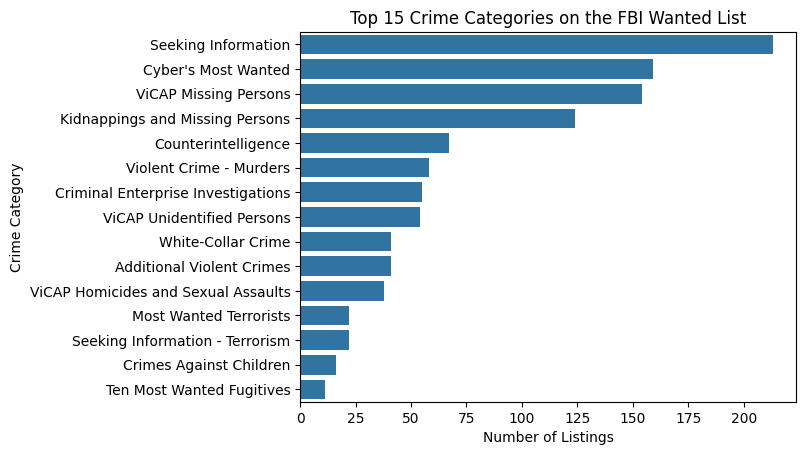

In [140]:
#count how many times each crime appears, keep + plot top 15 categories
crime_counts = df['primary_crime'].value_counts().head(15)

sns.barplot(x=crime_counts, y=crime_counts.index)
plt.title('Top 15 Crime Categories on the FBI Wanted List')
plt.xlabel('Number of Listings')
plt.ylabel('Crime Category')
plt.show()

Seeking Information is the largest category, which suggests that the FBI frequently uses the wanted list
to solicit tips from the public rather than just listing active fugitives. Cyber's Most Wanted and
ViCAP Missing Persons follow that and make up
a large share of the list. Traditional violent crime categories
are present but represent a smaller share than expected.

## Who is on the FBI Wanted List?

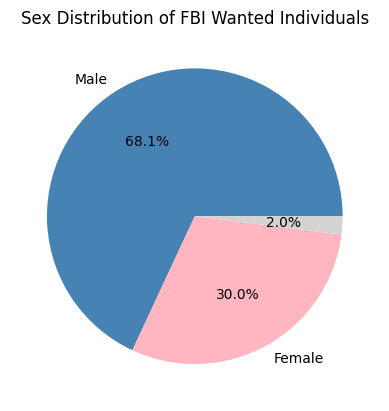

In [139]:
#count how many of each sex are on the list + plot
sex_counts = df['sex'].value_counts()

plt.pie(sex_counts, labels=sex_counts.index, autopct='%.1f%%', colors=['steelblue', 'lightpink', 'lightgray'])
plt.title('Sex Distribution of FBI Wanted Individuals')
plt.show()

The list is overwhelmingly male.
A small number of listings have no sex recorded, likely due to incomplete profiles.

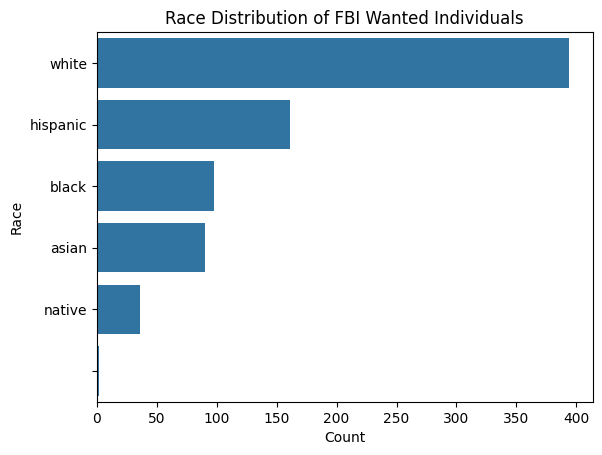

In [146]:
#count how many ppl of each race are on the list + plot
race_counts = df['race'].value_counts()

sns.barplot(x=race_counts.values, y=race_counts.index)
plt.title('Race Distribution of FBI Wanted Individuals')
plt.xlabel('Count')
plt.ylabel('Race')

plt.show()

White and Hispanic individuals make up the largest share of listings.

## Where are wanted individuals from?

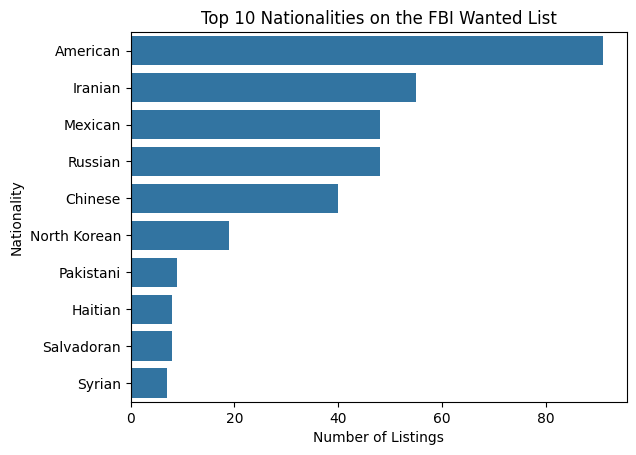

In [181]:
#count how many ppl from  each country, keep top 10
nationality_counts = df['nationality'].value_counts().head(10)

sns.barplot(x=nationality_counts.values, y=nationality_counts.index)
plt.title('Top 10 Nationalities on the FBI Wanted List')
plt.xlabel('Number of Listings')
plt.ylabel('Nationality')
plt.show()

Americans represent the largest group, but a lot of listings involve foreign nationals,
particularly from countries associated with counterintelligence investigations like China and Iran.

## Has the FBI Wanted List grown over time?

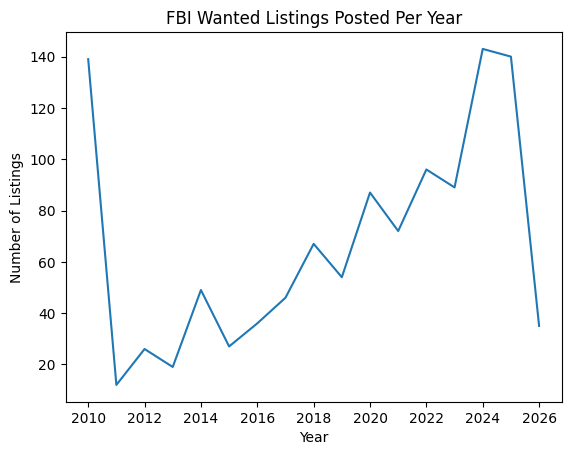

In [145]:
#count how many new listings per year and plot

yearly_counts = df['year_posted'].value_counts().sort_index()

sns.lineplot(x=yearly_counts.index, y=yearly_counts)
plt.title('FBI Wanted Listings Posted Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Listings')

plt.show()

The number of listings has grown steadily since 2010, with a notable spike in recent years.
This likely reflects both increased FBI resources dedicated to cybercrime and counterintelligence.

The spike in 2010 maybe reflects the initial launch of the FBI's digital wanted API, or when a large
batch of existing cases were uploaded at once.

## What factors are associated with higher rewards?

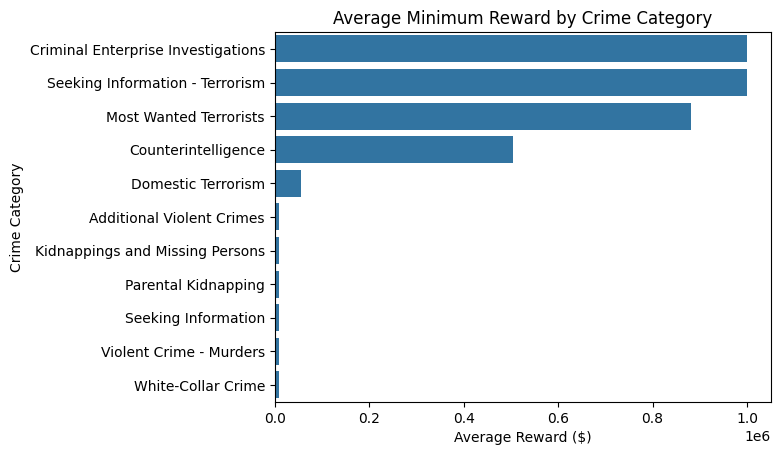

In [142]:
#only keep rows where a reward is offered
reward_df = df[df['reward_min'] > 0]

#calculate average reward for each crime type
mean_reward = reward_df.groupby('primary_crime')['reward_min'].mean().sort_values(ascending=False)

#plot
sns.barplot(x=mean_reward.values, y=mean_reward.index)
plt.title('Average Minimum Reward by Crime Category')
plt.xlabel('Average Reward ($)')
plt.ylabel('Crime Category')

plt.show()

"Criminal Enterprise Investigations" and "Seeking Information - Terrorism" both average the max reward of 1 million dollars. "Most Wanted Terrorists" follow closely at around 900k dollars, with "Counterintelligence" at around 500k. Categories like
violent crime and missing persons carry minimal or no rewards.

## How many listings actually include a reward?

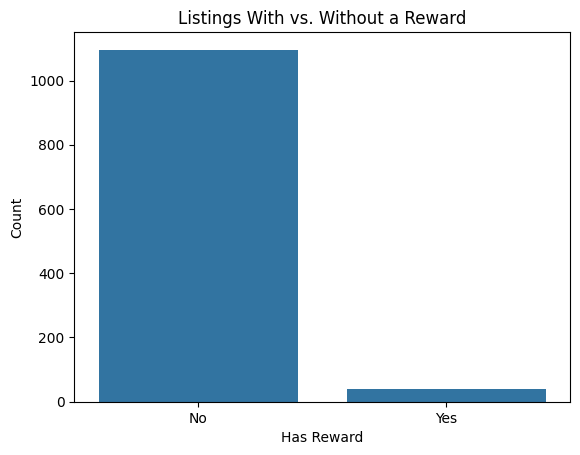

In [144]:
#count how many listings have a reward vs. not + plot
reward_share = df['has_reward'].value_counts()

sns.barplot(x=reward_share.index, y=reward_share)
plt.title('Listings With vs. Without a Reward')
plt.xlabel('Has Reward')
plt.ylabel('Count')
plt.show()

The majority of listings do not include a reward. Rewards tend to be reserved for high priority cases of national security.

## What does a typical wanted individual look like physically?

In [179]:
#only keep rows with realistic height and weight
height_weight_df = df[(df['height_min'] < 85) & (df['weight_min'] < 500) & (df['height_min'].notna()) & (df['weight_min'].notna())]

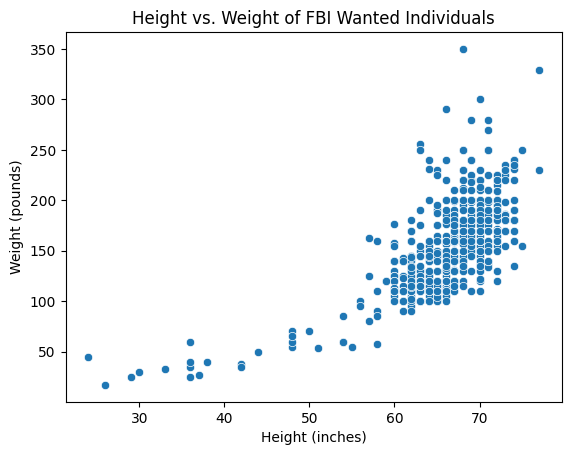

In [180]:
sns.scatterplot(data=height_weight_df, x='height_min', y='weight_min')
plt.title('Height vs. Weight of FBI Wanted Individuals')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.show()

The cluster between
60-75 inches and 140-220 pounds represents the typical adult male profile that dominates the list.
A small number of outliers with low height and weight mostly represent missing children cases.

Data cleaning was conducted to eliminate misinputs (10 feet tall, etc.)

## Conclusion
The FBI Wanted List is dominated by Seeking Information cases, cybercrime, and missing persons. The list serves a broader public engagement purpose beyond simply listing fugitives.
The list is overwhelmingly male, with White and Hispanic individuals making up the largest racial groups.
Reward amounts are highest for national security cases, with Criminal Enterprise Investigations and
terrorism-related listings averaging $1 million, the maximum reward offered. Physical profile data
clusters around a typical adult male range, with outliers likely representing missing children cases.